<a href="https://colab.research.google.com/github/jhelsas/fuks_cem/blob/main/Draft_Cross_Entropy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import numpy.random as rndm
import scipy as sp
import matplotlib.pyplot as plt
import heapq

# Otimizadores via Entropia Cruzada

## Versão 1 : Calcula média e variância conforme o Elite Sample

In [ ]:

def optimize_CE_v1(f, x0, n_in, n_out=None, N=100, p_elite=0.1, n_iter=1000, var = 20):
    medias = np.atleast_1d(np.asarray(x0, dtype=float)) if x0 is not None else np.zeros(n_in, dtype=float)
    desvios = np.full(n_in, var, dtype=float)
    candidates = [[x0],(medias,desvios)]

    n_elite = max(1, int(round(N * p_elite)))

    for _ in range(n_iter):

        samples_x = [np.random.normal(medias, desvios) for _ in range(N)]

        samples = [(f(x), x) for x in samples_x]

        samples.sort(key=lambda item: item[0])

        elite_xs = [item[1] for item in samples[:n_elite]]


        medias = np.mean(elite_xs, axis=0)
        desvios = np.std(elite_xs, axis=0)


        desvios = np.maximum(desvios, 1e-4)

        candidates.append((medias,desvios**2))

    return medias, desvios ** 2, candidates

In [ ]:
def f(v):
    x = v[0]
    return (x - 5)**2

In [ ]:
print(f"{optimize_CE_v1(f,[-5],1)[0]},optimize_CE_v1(f,[0],1)[1]")
candidates = optimize_CE_v1(f,[-5],1)[2]

[4.99999441],optimize_CE_v1(f,[0],1)[1]


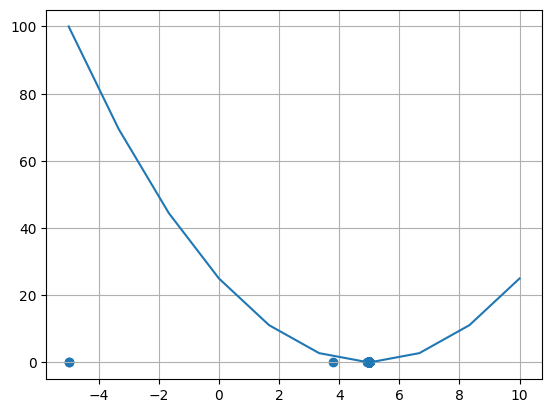

In [ ]:
plt.scatter([c[0] for c in candidates],np.zeros(1002))
plt.plot(np.linspace(-5,10,10 ), [f([x]) for x in np.linspace(-5,10,10) ])
plt.grid();

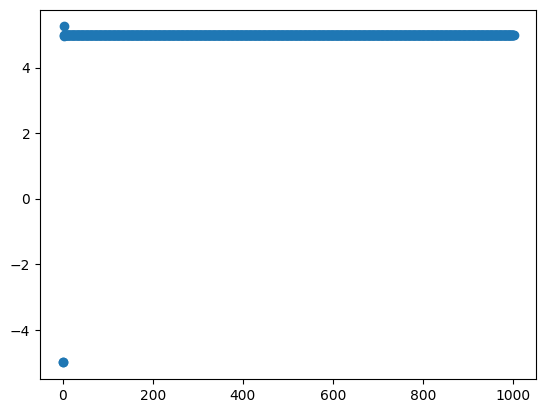

In [ ]:
plt.scatter([i for i in range(len(candidates))], [c[0] for c in candidates])

# Funções de Teste

In [ ]:
def beale(v):
  x,y = v[0],v[1]
  return (1.5 - x + x*y)**2 + (2.25-x + x*y*y)**2 + (2.625 - x + x*y*y*y)**2

2.096784

# Surrogate

In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor


def interpolate_then_optimize(X, y, K, M, x0):

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).ravel()
    x0 = np.asarray(x0, dtype=float)

    n, m = X.shape

    # Média nos pontos observados
    M_X = np.array([M(x) for x in X])

    # Resíduos em relação à média
    y_residual = y - M_X

    # GP sem ruído: interpolação exata
    gp = GaussianProcessRegressor(
        kernel=K,
        alpha=0.0,
        optimizer=None
    )

    gp.fit(X, y_residual)

    # Função interpolada
    def f_prime(x):
        x = np.asarray(x, dtype=float)

        residual, uncertainty = gp.predict(x.reshape(1, -1))

        return float(M(x) + residual - kappa * uncertainty)

    # Otimização
    return optimize_CE_v1(
        f_prime,
        x0,
        m
    ), f_prime

# Teste na função Beale

In [ ]:
import numpy as np
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

np.random.seed(42)

n_samples = 200

X = np.random.uniform(
    low=-4.5,
    high=4.5,
    size=(n_samples, 2)
)

y = np.array([
    beale(x)
    for x in X
])

K = ConstantKernel(1.0) * RBF(length_scale=1.0)

M = lambda x: 0.0


x0 = np.array([0.0, 0.0])


(result, f_prime) = interpolate_then_optimize(
    X, y, K, M, x0
)

x_opt, variance_opt, candidates = result

f_opt = f_prime(x_opt)

print("Ponto encontrado:", x_opt)
print("Valor da função interpolada:", f_opt)
print("Valor verdadeiro:", beale(x_opt))

Ponto encontrado: [5.72924787 0.23040101]
Valor da função interpolada: -4131.525433407582
Valor verdadeiro: 27.75113941671491


##Valor nos pontos interpolados

In [ ]:
y_gp = np.array([f_prime(x) for x in X])

print("y real:")
print(y)

print("\ny GP:")
print(y_gp)

print("\nerro máximo:")
print(np.max(np.abs(y_gp - y)))

y real:
[5.36320427e+03 8.86730895e+00 1.03181065e+04 1.98544214e+04
 8.49509069e+01 1.07183342e+05 3.19216502e+03 5.63135970e+03
 4.27068964e+01 6.44357841e+01 1.22147574e+03 9.36629267e+01
 1.42031503e+01 6.72943330e+01 3.24128715e+03 6.57356949e+02
 6.67310782e+04 8.75205174e+03 8.17619251e+03 2.75720708e+00
 9.36883163e+01 4.37190444e+04 4.28747091e+00 4.20432446e+01
 8.17484543e+01 4.54734092e+03 3.34903697e+04 2.71092673e+03
 7.46510252e+03 6.70484696e+02]

y GP:
[5.36320427e+03 8.86730895e+00 1.03181065e+04 1.98544214e+04
 8.49509069e+01 1.07183342e+05 3.19216502e+03 5.63135970e+03
 4.27068964e+01 6.44357841e+01 1.22147574e+03 9.36629267e+01
 1.42031503e+01 6.72943330e+01 3.24128715e+03 6.57356949e+02
 6.67310782e+04 8.75205174e+03 8.17619251e+03 2.75720708e+00
 9.36883163e+01 4.37190444e+04 4.28747091e+00 4.20432446e+01
 8.17484543e+01 4.54734092e+03 3.34903697e+04 2.71092673e+03
 7.46510252e+03 6.70484696e+02]

erro máximo:
1.3096723705530167e-10
